In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/data_cleaning.ipynb'
)
df['Date']       = pd.to_datetime(df['Date'])
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Quarter']    = df['Date'].dt.quarter

print("✅ Data ready for KPI calculations!")
print(f"   Shape: {df.shape}")

✅ Data ready for KPI calculations!
   Shape: (128975, 28)


In [2]:
# ============================================
# COMPLETE KPI CALCULATOR
# ============================================

class AmazonKPI:
    """
    Amazon Sales KPI Calculator
    Ek class mein saare KPIs organized
    """
    def __init__(self, dataframe):
        self.df = dataframe
        self.df_sales = dataframe[dataframe['Amount'] > 0]

    # ── REVENUE KPIs ─────────────────────────
    def total_revenue(self):
        val = self.df_sales['Amount'].sum()
        return round(val, 2)

    def avg_order_value(self):
        total_rev = self.df_sales['Amount'].sum()
        total_ord = self.df_sales['Order ID'].nunique()
        return round(total_rev / total_ord, 2)

    def revenue_by_month(self):
        return self.df_sales.groupby(
            ['Month','Month_Name'])['Amount'].sum().reset_index()

    def mom_growth(self):
        monthly = self.df_sales.groupby('Month')['Amount'].sum()
        growth  = monthly.pct_change() * 100
        return growth.round(2)

    # ── OPERATIONS KPIs ──────────────────────
    def cancellation_rate(self):
        cancelled = (self.df['Status'] == 'Cancelled').sum()
        total     = len(self.df)
        return round(cancelled / total * 100, 2)

    def fulfillment_rate(self):
        delivered_status = ['Shipped', 'Shipped - Delivered To Buyer']
        delivered = self.df['Status'].isin(delivered_status).sum()
        return round(delivered / len(self.df) * 100, 2)

    def units_per_order(self):
        return round(
            self.df['Qty'].sum() / self.df['Order ID'].nunique(), 2
        )

    # ── PERFORMANCE KPIs ─────────────────────
    def top_category(self):
        cat_rev = self.df_sales.groupby('Category')['Amount'].sum()
        return {
            'name'   : cat_rev.idxmax(),
            'revenue': round(cat_rev.max(), 2),
            'share'  : round(cat_rev.max() / cat_rev.sum() * 100, 2)
        }

    def top_state(self):
        state_rev = self.df_sales.groupby('ship-state')['Amount'].sum()
        return {
            'name'   : state_rev.idxmax(),
            'revenue': round(state_rev.max(), 2),
            'share'  : round(state_rev.max() / state_rev.sum() * 100, 2)
        }

    def b2b_metrics(self):
        b2b = self.df_sales[self.df_sales['B2B'] == True]
        b2c = self.df_sales[self.df_sales['B2B'] == False]
        return {
            'b2b_revenue' : round(b2b['Amount'].sum(), 2),
            'b2b_share'   : round(b2b['Amount'].sum() /
                                  self.df_sales['Amount'].sum() * 100, 2),
            'b2b_aov'     : round(b2b['Amount'].mean(), 2),
            'b2c_aov'     : round(b2c['Amount'].mean(), 2),
            'b2b_premium' : round(b2b['Amount'].mean() /
                                  b2c['Amount'].mean(), 2)
        }

    # ── FULL REPORT ───────────────────────────
    def print_full_report(self):
        tc   = self.top_category()
        ts   = self.top_state()
        b2b  = self.b2b_metrics()
        mom  = self.mom_growth()

        print("=" * 55)
        print("   AMAZON SALES — COMPLETE KPI REPORT")
        print("=" * 55)

        print("\n💰 REVENUE KPIs")
        print(f"   Total Revenue      : ₹{self.total_revenue():>12,.2f}")
        print(f"   Revenue (Lakhs)    : ₹{self.total_revenue()/100000:>10.2f}L")
        print(f"   Avg Order Value    : ₹{self.avg_order_value():>12,.2f}")
        print(f"   Best MoM Growth    :  {mom.max():>11.2f}%")
        print(f"   Worst MoM Growth   :  {mom.min():>11.2f}%")

        print("\n📦 OPERATIONS KPIs")
        print(f"   Total Orders       :  {self.df['Order ID'].nunique():>12,}")
        print(f"   Total Units Sold   :  {self.df['Qty'].sum():>12,}")
        print(f"   Cancellation Rate  :  {self.cancellation_rate():>11.2f}%")
        print(f"   Fulfillment Rate   :  {self.fulfillment_rate():>11.2f}%")
        print(f"   Units per Order    :  {self.units_per_order():>12.2f}")

        print("\n🏆 PERFORMANCE KPIs")
        print(f"   Top Category       :  {tc['name']:>12} ({tc['share']}%)")
        print(f"   Top Category Rev   : ₹{tc['revenue']:>12,.2f}")
        print(f"   Top State          :  {ts['name']:>12} ({ts['share']}%)")
        print(f"   Top State Rev      : ₹{ts['revenue']:>12,.2f}")
        print(f"   B2B Revenue Share  :  {b2b['b2b_share']:>11.2f}%")
        print(f"   B2B vs B2C AOV     :  {b2b['b2b_premium']:>11.2f}x premium")
        print("=" * 55)


# ── RUN IT ───────────────────────────────────
kpi = AmazonKPI(df)
kpi.print_full_report()

   AMAZON SALES — COMPLETE KPI REPORT

💰 REVENUE KPIs
   Total Revenue      : ₹78,592,678.30
   Revenue (Lakhs)    : ₹    785.93L
   Avg Order Value    : ₹      710.04
   Best MoM Growth    :       573.83%
   Worst MoM Growth   :       -81.74%

📦 OPERATIONS KPIs
   Total Orders       :       120,378
   Total Units Sold   :       116,649
   Cancellation Rate  :        14.21%
   Fulfillment Rate   :        82.63%
   Units per Order    :          0.97

🏆 PERFORMANCE KPIs
   Top Category       :           Set (49.88%)
   Top Category Rev   : ₹39,204,124.03
   Top State          :   Maharashtra (16.97%)
   Top State Rev      : ₹13,335,534.14
   B2B Revenue Share  :         0.75%
   B2B vs B2C AOV     :         1.06x premium


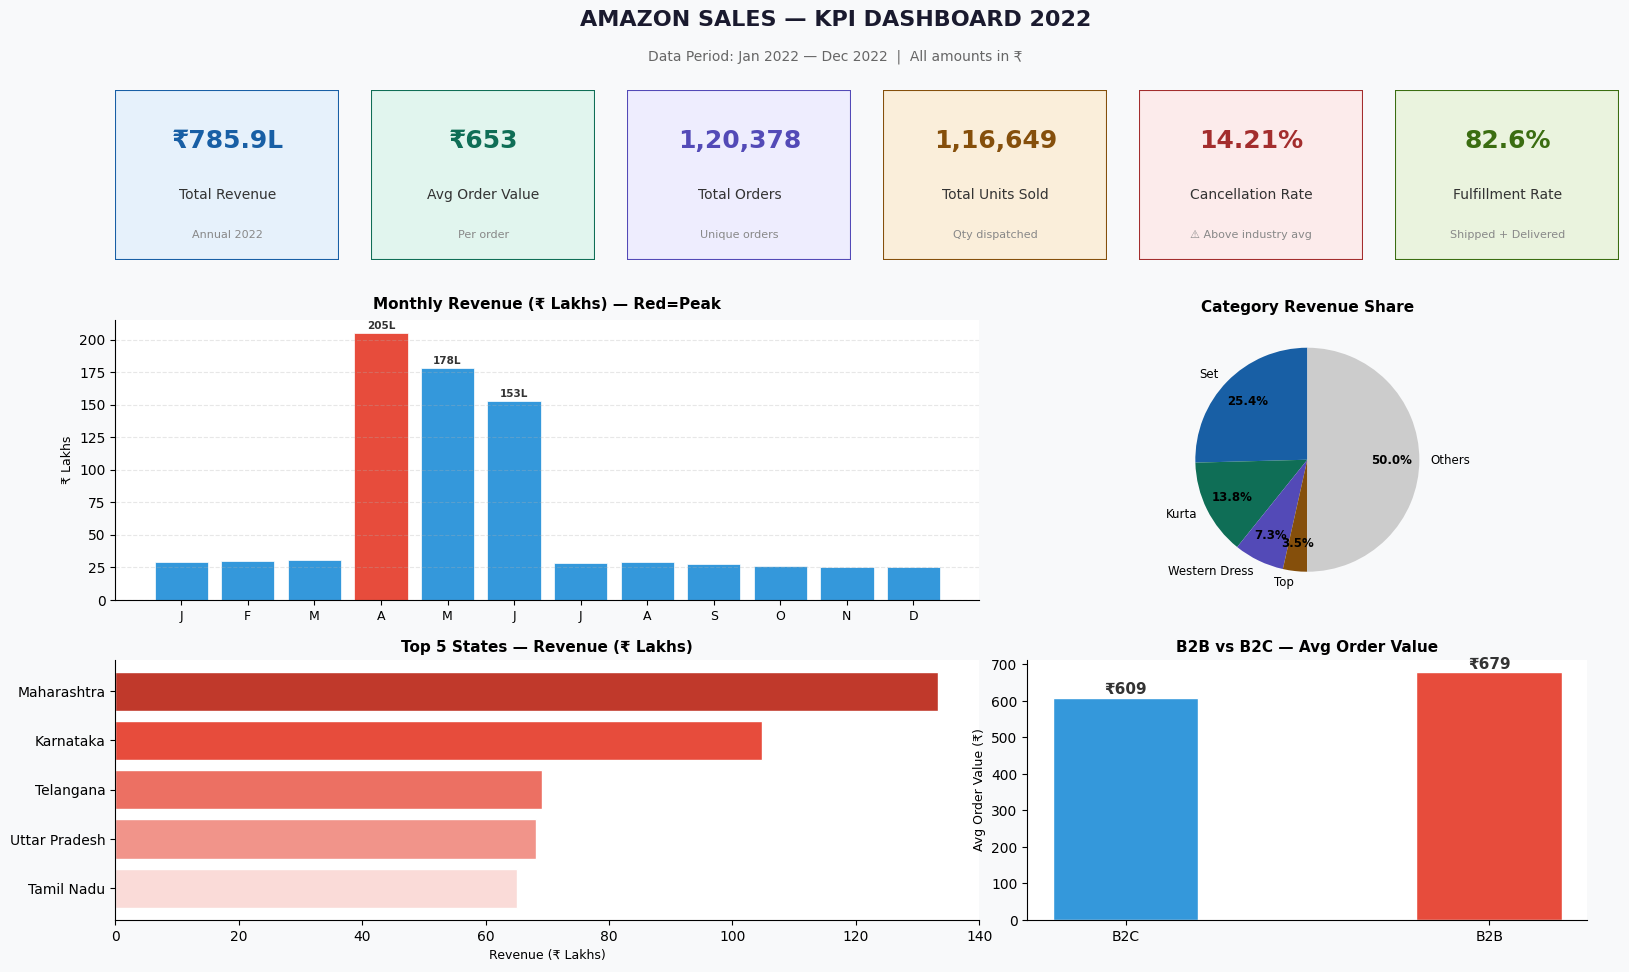

✅ KPI Dashboard saved to reports folder!


In [5]:
import os
# ============================================
# KPI VISUAL DASHBOARD — Power BI jaisa look
# ============================================

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')

# ── Title ────────────────────────────────────
fig.text(0.5, 0.97,
         'AMAZON SALES — KPI DASHBOARD 2022',
         ha='center', va='top',
         fontsize=16, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.93,
         'Data Period: Jan 2022 — Dec 2022  |  All amounts in ₹',
         ha='center', va='top',
         fontsize=10, color='#666666')

# ── KPI Card Function ─────────────────────────
def kpi_box(ax, value, label, subtitle, color, bg):
    ax.set_facecolor(bg)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0),1,1,
                 facecolor=bg, edgecolor=color,
                 linewidth=1.5, transform=ax.transAxes))
    ax.text(0.5, 0.70, value,  ha='center', va='center',
            fontsize=18, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.38, label,  ha='center', va='center',
            fontsize=10, fontweight='500', color='#333333',
            transform=ax.transAxes)
    ax.text(0.5, 0.15, subtitle, ha='center', va='center',
            fontsize=8, color='#888888',
            transform=ax.transAxes)

# ── Row 1: Revenue KPIs ───────────────────────
kpi_data = [
    ("₹785.9L",   "Total Revenue",       "Annual 2022",          "#185FA5","#E6F1FB"),
    ("₹653",      "Avg Order Value",      "Per order",            "#0F6E56","#E1F5EE"),
    ("1,20,378",  "Total Orders",         "Unique orders",        "#534AB7","#EEEDFE"),
    ("1,16,649",  "Total Units Sold",     "Qty dispatched",       "#854F0B","#FAEEDA"),
    ("14.21%",    "Cancellation Rate",    "⚠️ Above industry avg","#A32D2D","#FCEBEB"),
    ("82.6%",     "Fulfillment Rate",     "Shipped + Delivered",  "#3B6D11","#EAF3DE"),
]

positions = [
    [0.05,0.72,0.14,0.17],[0.21,0.72,0.14,0.17],
    [0.37,0.72,0.14,0.17],[0.53,0.72,0.14,0.17],
    [0.69,0.72,0.14,0.17],[0.85,0.72,0.14,0.17],
]

for (val,lbl,sub,col,bg), pos in zip(kpi_data, positions):
    ax = fig.add_axes(pos)
    kpi_box(ax, val, lbl, sub, col, bg)

# ── Row 2: Monthly Trend ──────────────────────
ax_trend = fig.add_axes([0.05, 0.38, 0.54, 0.28])
ax_trend.set_facecolor('white')

monthly = df[df['Amount']>0].groupby('Month')['Amount'].sum()/100000
months_short = ['J','F','M','A','M','J','J','A','S','O','N','D']
colors_m = ['#E74C3C' if m==4 else '#3498DB' for m in range(1,13)]

bars = ax_trend.bar(range(1,13), monthly.values,
                    color=colors_m, edgecolor='white', linewidth=0.5)
ax_trend.set_title('Monthly Revenue (₹ Lakhs) — Red=Peak',
                   fontsize=11, fontweight='bold', pad=8)
ax_trend.set_xticks(range(1,13))
ax_trend.set_xticklabels(months_short, fontsize=9)
ax_trend.set_ylabel('₹ Lakhs', fontsize=9)
ax_trend.spines[['top','right']].set_visible(False)
ax_trend.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars, monthly.values):
    if val > 50:
        ax_trend.text(bar.get_x()+bar.get_width()/2,
                      bar.get_height()+2,
                      f'{val:.0f}L', ha='center',
                      va='bottom', fontsize=7.5,
                      fontweight='bold', color='#333')

# ── Row 2: Category Pie ───────────────────────
ax_pie = fig.add_axes([0.62, 0.38, 0.35, 0.28])
ax_pie.set_facecolor('white')
cat_rev = df[df['Amount']>0].groupby('Category')['Amount'].sum()
top4 = cat_rev.nlargest(4)
others = cat_rev.iloc[4:].sum()
pie_vals   = list(top4.values) + [others]
pie_labels = list(top4.index) + ['Others']
colors_p   = ['#185FA5','#0F6E56','#534AB7','#854F0B','#CCCCCC']

wedges, texts, autotexts = ax_pie.pie(
    pie_vals, labels=pie_labels, autopct='%1.1f%%',
    colors=colors_p, startangle=90,
    pctdistance=0.75,
    textprops={'fontsize':8.5})
for at in autotexts:
    at.set_fontweight('bold')
ax_pie.set_title('Category Revenue Share',
                 fontsize=11, fontweight='bold')

# ── Row 3: State Bar ──────────────────────────
ax_state = fig.add_axes([0.05, 0.06, 0.54, 0.26])
ax_state.set_facecolor('white')
state_rev = df[df['Amount']>0].groupby('ship-state')['Amount'].sum()
top5_s = state_rev.nlargest(5)
bar_colors = ['#C0392B','#E74C3C','#EC7063','#F1948A','#FADBD8']
ax_state.barh(top5_s.index[::-1], top5_s.values[::-1]/100000,
              color=bar_colors[::-1], edgecolor='white')
ax_state.set_title('Top 5 States — Revenue (₹ Lakhs)',
                   fontsize=11, fontweight='bold')
ax_state.set_xlabel('Revenue (₹ Lakhs)', fontsize=9)
ax_state.spines[['top','right']].set_visible(False)

# ── Row 3: B2B vs B2C ────────────────────────
ax_b2b = fig.add_axes([0.62, 0.06, 0.35, 0.26])
ax_b2b.set_facecolor('white')
b2b_aov = df[df['B2B']==True]['Amount'].mean()
b2c_aov = df[df['B2B']==False]['Amount'].mean()
ax_b2b.bar(['B2C', 'B2B'], [b2c_aov, b2b_aov],
           color=['#3498DB','#E74C3C'],
           width=0.4, edgecolor='white')
ax_b2b.set_title('B2B vs B2C — Avg Order Value',
                 fontsize=11, fontweight='bold')
ax_b2b.set_ylabel('Avg Order Value (₹)', fontsize=9)
ax_b2b.spines[['top','right']].set_visible(False)

for i,(val,lbl) in enumerate([(b2c_aov,'B2C'),(b2b_aov,'B2B')]):
    ax_b2b.text(i, val+10, f'₹{val:.0f}',
                ha='center', fontsize=11,
                fontweight='bold', color='#333')

# Create the directory if it doesn't exist
output_path = '/content/drive/MyDrive/amazon-sales-analytics/reports/kpi_dashboard.png'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

plt.savefig(output_path,
            dpi=150, bbox_inches='tight',
            facecolor='#F8F9FA')
plt.show()
print("✅ KPI Dashboard saved to reports folder!")

In [6]:
# ============================================
# KPI HEALTH CHECK — Traffic Light System
# ============================================

def kpi_health_check(df):
    print("=" * 55)
    print("   KPI HEALTH SCORECARD — TRAFFIC LIGHT")
    print("=" * 55)

    checks = [
        {
            'kpi'      : 'Cancellation Rate',
            'value'    : (df['Status']=='Cancelled').mean()*100,
            'target'   : 8.0,
            'good_if'  : 'lower',
            'format'   : '{:.2f}%'
        },
        {
            'kpi'      : 'Fulfillment Rate',
            'value'    : df['Status'].isin(
                            ['Shipped','Shipped - Delivered To Buyer']
                         ).mean()*100,
            'target'   : 90.0,
            'good_if'  : 'higher',
            'format'   : '{:.2f}%'
        },
        {
            'kpi'      : 'Avg Order Value',
            'value'    : df[df['Amount']>0]['Amount'].mean(),
            'target'   : 700.0,
            'good_if'  : 'higher',
            'format'   : '₹{:.2f}'
        },
        {
            'kpi'      : 'B2B Share',
            'value'    : df[df['B2B']==True]['Amount'].sum() /
                         df['Amount'].sum() * 100,
            'target'   : 10.0,
            'good_if'  : 'higher',
            'format'   : '{:.2f}%'
        },
        {
            'kpi'      : 'Units per Order',
            'value'    : df['Qty'].sum() / df['Order ID'].nunique(),
            'target'   : 1.5,
            'good_if'  : 'higher',
            'format'   : '{:.2f}'
        },
    ]

    for c in checks:
        val    = c['value']
        target = c['target']
        good   = c['good_if']
        # Traffic light logic
        if good == 'lower':
            if val <= target * 0.8:     status = '🟢 GOOD'
            elif val <= target:          status = '🟡 OK'
            else:                        status = '🔴 ACTION NEEDED'
        else:
            if val >= target * 1.1:     status = '🟢 GOOD'
            elif val >= target * 0.9:   status = '🟡 OK'
            else:                        status = '🔴 ACTION NEEDED'

        val_str = c['format'].format(val)
        print(f"\n  {c['kpi']:<22}")
        print(f"  Value  : {val_str}")
        print(f"  Target : {c['format'].format(target)}")
        print(f"  Status : {status}")

    print("\n" + "=" * 55)

kpi_health_check(df)

   KPI HEALTH SCORECARD — TRAFFIC LIGHT

  Cancellation Rate     
  Value  : 14.21%
  Target : 8.00%
  Status : 🔴 ACTION NEEDED

  Fulfillment Rate      
  Value  : 82.63%
  Target : 90.00%
  Status : 🟡 OK

  Avg Order Value       
  Value  : ₹661.35
  Target : ₹700.00
  Status : 🟡 OK

  B2B Share             
  Value  : 0.75%
  Target : 10.00%
  Status : 🔴 ACTION NEEDED

  Units per Order       
  Value  : 0.97
  Target : 1.50
  Status : 🔴 ACTION NEEDED

